In [71]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
import xgboost as xgb

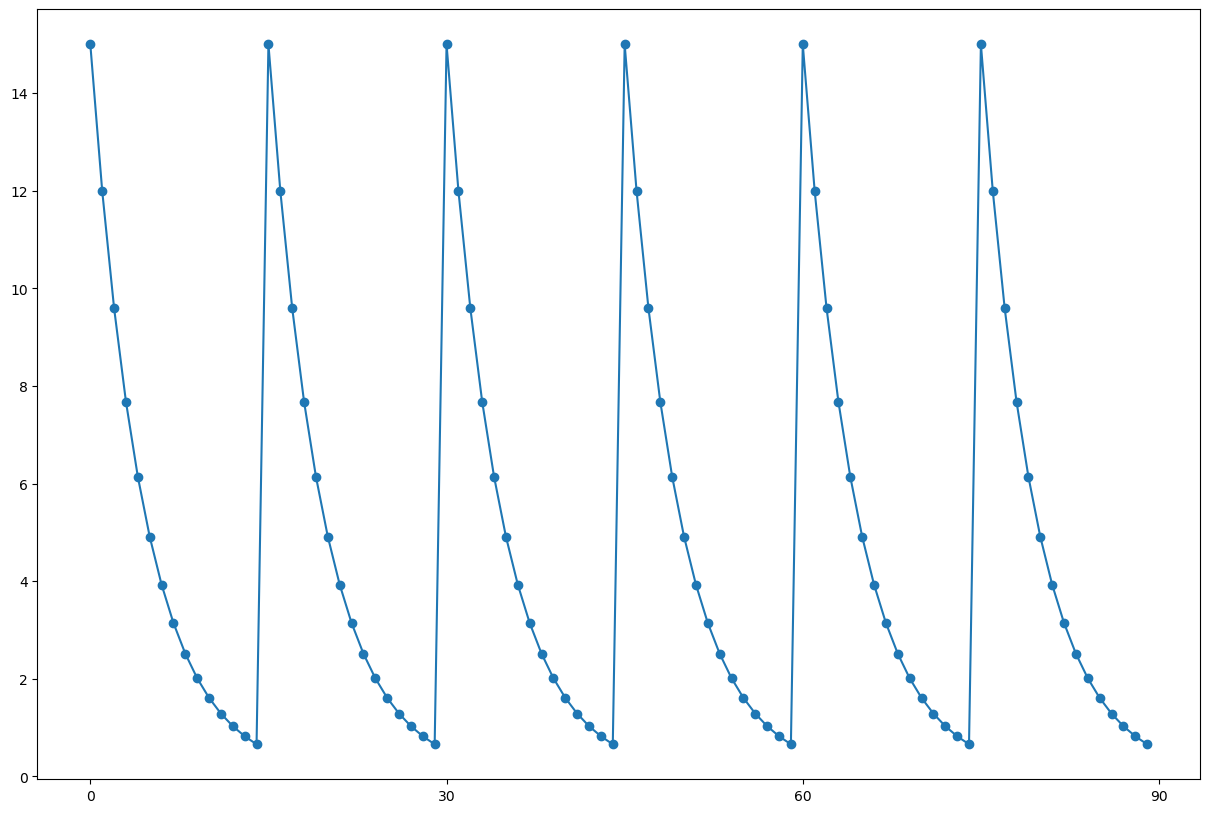

In [72]:
total_steps = 5000000
base_reward = 15.0
decay_rate = 0.8
reward_period = 15 

rewards_in_period = []
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))
plt.figure(figsize=(15, 10))
plt.plot(np.arange(0,90),rewards_in_period[:90],marker = 'o')
plt.xticks([0,30,60,90])


def reward_simulate_2d(state, t,rewards_in_period):
    state = np.asarray(state, dtype=int)
    phase = t % 30
    if np.array_equal(state, np.array([1,1])) and phase < 15:
        return float(rewards_in_period[t])
    if np.array_equal(state, np.array([5,5])) and phase >= 15:
        return float(rewards_in_period[t])
    return 0.0

def step_at_bounds(state, action, size=7):
    candidate = state + action
    # If candidate goes out of bounds, stay; else move.
    if (candidate < 0).any() or (candidate >= size).any():
        return state.copy()
    return candidate


def simulate_data_raw(rewards_in_period, session_duration = 10000,tdim=50, n_sessions=10,seed  = 515):
    """
    Simulate training and testing data with rewards from a given environment.


    Returns:
    - actions, state, ireward, times: np.ndarrays
    """

    np.random.seed(seed)
    actions, states, irewards,times = [], [], [], []
    # state_initial = int(np.random.choice(np.arange(7)))
    state_initial = [1,1]
    for episode in range(n_sessions):
        t = 0
        episode_data = []
        state = state_initial
        for _ in range(session_duration):
            ireward = reward_simulate_2d(state, t, rewards_in_period)
            # print(len(state))
            state_vec = np.array([state]).reshape(1,len(state))  # shape (1, state_dim)
            time_emb = time_embedding_np(t+1, tdim=tdim).reshape(1,tdim)
            # print(state_vec.shape,time_emb.shape)
            features = np.hstack([state_vec, time_emb])
            ACTIONS = np.array([[0,1],[0,-1],[-1,0],[1,0],[0,0]], dtype=int)
            idx = np.random.randint(len(ACTIONS))
            action = ACTIONS[idx] # up,down, left right
            next_state = step_at_bounds(state, action, size=7)
            episode_data.append((action,features,ireward))
            state = next_state
            t += 1
        for i, (action, features, ireward) in enumerate(episode_data):
            actions.append(action)
            states.append(features)
            irewards.append(ireward)
            times.append(i)

    return (
        np.array(actions),
        np.array(states),
        np.array(irewards),
        np.array(times),
    )

In [73]:
ACTIONS = np.array([[0,1],[0,-1],[-1,0],[1,0],[0,0]], dtype=int)
def _in_bounds(pos, size):
    return 0 <= pos[0] < size and 0 <= pos[1] < size

def get_candidates_2d(state, t, size=7):
    sx, sy = (int(state[0]), int(state[1]))
    curr_state = np.array([sx, sy], dtype=int)
    cands = []
    for d in ACTIONS:
        next_state = curr_state + d
        if _in_bounds(next_state, size):
            cands.append((int(next_state[0]), int(next_state[1])))
        else:
            cands.append((sx, sy))
    seen, uniq = set(), []
    for s in cands:
        if s not in seen:
            seen.add(s)
            uniq.append(s)
    return uniq

def enumerate_paths_2d(x0, t_initial=0, t_prime=20, size=7):
    x0 = (int(x0[0]), int(x0[1]))
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates_2d(curr, t, size=size):
                new_paths.append(path + [nxt])
        paths = new_paths

    cols = [f"t={t_initial+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

In [141]:
gamma = 0.99
# Ts = [2**i for i in np.arange(7,8)]+[150,200,225,256,300,400,512]+[750]+[1024,1250,1500,2048]
# Ts = [600,1200,3000,6000,12000,24000,48000]
Ts = [12000,24000]
# Ts = [96000]
threshold = 1e-4
## Onehot Encoding
for rep in range(1):
    for t_prime in [9]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
        state_posencode_oh_x = position_encoder(states[:,:,0], type="onehot")
        state_posencode_oh_y = position_encoder(states[:,:,1], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh_y,state_posencode_oh_x,states[:,0,2:]])
        # np.random.shuffle(irewards)
        for T in Ts:
            prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)
            X_train_oh = new_state_oh[:T,:]
            Y_train_value = prewards[:T]
            Y_train_action = irewards[:T]
            # is_pos = (Y_train_value > threshold).astype(int)
            # pos = is_pos.sum()
            # neg = len(Y_train_value) - pos
            # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
            rf_value = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact", 
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse")
            # rf_value.fit(X_train_oh, Y_train_value, sample_weight=w)
            rf_value.fit(X_train_oh, Y_train_value)

            
            rf_action = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact", 
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse")
            rf_action.fit(X_train_oh, Y_train_action)

            print(T,'train done')
            current_state = states[T,0,:2]
            print(current_state)
            future_states = [current_state]
            for delta_t in range(60):
                df_all_paths = enumerate_paths_2d(x0=current_state,t_initial = T+delta_t,t_prime=t_prime)
                # print(f"Total paths: {len(df_all_paths)}")
                # states_seq = df_all_paths[state_cols].to_numpy() 

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    next_state = df_all_paths.iloc[:,i]
                    next_state_x = np.array([next_state[i][0] for i in range(df_all_paths.shape[0])])
                    next_state_y = np.array([next_state[i][1] for i in range(df_all_paths.shape[0])])
                    cand_pe_x = position_encoder(next_state_x, type="onehot")
                    cand_pe_y = position_encoder(next_state_y, type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(np.ones(cand_pe_y.shape[0])*curr_time, tdim=50)
                    features = np.hstack([cand_pe_x,cand_pe_y,time_emb])
                    irewards_pred[:,i] = rf_action.predict(features)
                # # Convert to DataFrame for inspection
                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)


                next_state = df_all_paths.iloc[:,-1]
                next_state_x = np.array([next_state[i][0] for i in range(df_all_paths.shape[0])])
                next_state_y = np.array([next_state[i][1] for i in range(df_all_paths.shape[0])])
                cand_pe_x = position_encoder(next_state_x, type="onehot")
                cand_pe_y = position_encoder(next_state_y, type="onehot")
                curr_time = T+1+delta_t+t_prime+1
                time_emb = time_embedding_np(np.ones(cand_pe_x.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe_x,cand_pe_y,time_emb])
                
                prewards_pred = rf_value.predict(features)
                df_ireward[f"preward"] = prewards_pred
                rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
                discounts = gamma ** np.arange(0, t_prime+1)

                discounted_returns = rewards_matrix * discounts # PVAFM
                # discounted_returns = rewards_matrix[:,:-1] * discounts[:-1] 
                # total_discounted = discounted_returns.sum(axis=1)+ 7*df_ireward.iloc[:,-1].values
                # print(rewards_matrix.shape)
                # Compute discounted total reward per path
                # discounted_returns = rewards_matrix * discounts  
                total_discounted = discounted_returns.sum(axis=1)
                # print(total_discounted)
                bext_idx = np.argmax(total_discounted)
                next_state = df_all_paths.iloc[bext_idx,1]
                # print(df_all_paths.iloc[bext_idx,:])
                future_states.append(next_state)
                current_state = next_state
                print(T+delta_t+1,current_state)
            print(T,future_states,len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate_2d(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,60,0.5,normalization = True)
            # path, ireward_opt = path_opt(future_states[0], T, 100)
            # preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5,normalization = True)
            # pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            # print(pregret)
            # plt.plot(np.arange(T+1,T+101),future_states[1:])
            # plt.plot(np.arange(1,101,1),states[:100,:,1])
            # plt.show()
            # plt.plot( np.arange(1,101,1),states[:100,:,0])
            # plt.show()
            print(np.sum(preward)/60)
            np.savez(
                f"../results/2D/RF_oh_w_time{T}_lookahead{t_prime}_reps{rep}.npz",
                future_states =FUTURE_STATE
                )
        # FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        # np.savez(
        # f"../results/2D/RF_oh_w_time1000_240000_lookahead{t_prime}_reps{rep}.npz",
        # future_states =FUTURE_STATE_arr
        # )

12000 train done
[6. 4.]
12001 (6, 3)
12002 (6, 2)
12003 (6, 1)
12004 (5, 1)
12005 (4, 1)
12006 (3, 1)
12007 (2, 1)
12008 (2, 1)
12009 (3, 1)
12010 (4, 1)
12011 (5, 1)
12012 (5, 2)
12013 (5, 3)
12014 (5, 4)
12015 (5, 5)
12016 (5, 5)
12017 (5, 5)
12018 (5, 5)
12019 (5, 5)
12020 (5, 5)
12021 (5, 5)
12022 (5, 5)
12023 (5, 4)
12024 (4, 4)
12025 (4, 3)
12026 (4, 2)
12027 (3, 2)
12028 (3, 1)
12029 (2, 1)
12030 (1, 1)
12031 (1, 1)
12032 (1, 1)
12033 (1, 1)
12034 (1, 1)
12035 (1, 1)
12036 (1, 1)
12037 (1, 1)
12038 (1, 2)
12039 (1, 3)
12040 (2, 3)
12041 (3, 3)
12042 (3, 4)
12043 (4, 4)
12044 (4, 5)
12045 (5, 5)
12046 (5, 5)
12047 (5, 5)
12048 (5, 5)
12049 (5, 5)
12050 (5, 5)
12051 (5, 5)
12052 (5, 5)
12053 (5, 4)
12054 (5, 3)
12055 (4, 3)
12056 (4, 2)
12057 (3, 2)
12058 (3, 1)
12059 (2, 1)
12060 (1, 1)
12000 [array([6., 4.]), (6, 3), (6, 2), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5, 5), (5,

In [41]:
prewards = []
Ts =  [600,1200,3000,6000,12000,24000]
print(len(FUTURE_STATE))
pregrets = []
for i in np.arange(len(Ts)): 
    T = Ts[i]
    future_states = paths[i]
    np.savez(f"../results/2D/RF_oh_w_time{T}_lookahead{9}_reps{1}.npz",future_states =future_states)
    print(len(future_states))
    irewards_test = [reward_simulate_2d(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    print(irewards_test)
    preward = compute_normalized_future_rewards(irewards_test,60,0.5,normalization = True)
    prewards.append(np.sum(preward))
    pregrets.append((215-(np.sum(preward)))/60)

6
61
[12.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0, 12.0, 9.600000000000001, 7.6800000000000015, 6.144000000000001, 4.915200000000001, 3.9321600000000014, 0.0, 0.0, 2.013265920000001, 1.6106127360000009, 1.2884901888000007, 1.0307921510400007, 0.8246337208320006, 0.6597069766656005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0, 12.0, 9.600000000000001, 7.6800000000000015, 6.144000000000001, 4.915200000000001, 3.9321600000000014, 3.145728000000001, 2.516582400000001, 2.013265920000001, 1.6106127360000009, 1.2884901888000007, 1.0307921510400007, 0.8246337208320006, 0.6597069766656005, 0.0]
61
[0.0, 0.0, 0.0, 6.144000000000001, 4.915200000000001, 3.9321600000000014, 3.145728000000001, 2.516582400000001, 2.013265920000001, 1.6106127360000009, 1.2884901888000007, 1.0307921510400007, 0.8246337208320006, 0.6597069766656005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0, 12.0, 9.600000000000001,

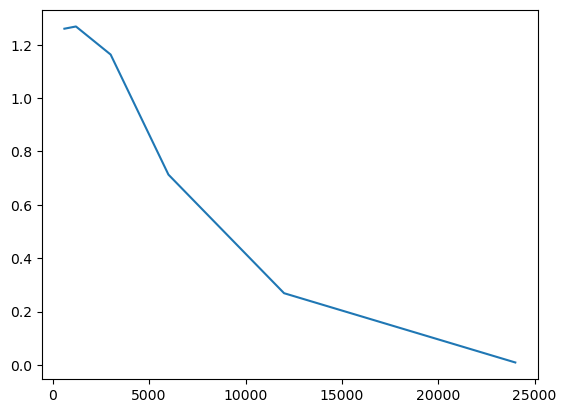

In [25]:
plt.plot(Ts,pregrets)

61
[12.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0, 12.0, 9.600000000000001, 7.6800000000000015, 6.144000000000001, 4.915200000000001, 3.9321600000000014, 0.0, 0.0, 2.013265920000001, 1.6106127360000009, 1.2884901888000007, 1.0307921510400007, 0.8246337208320006, 0.6597069766656005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0, 12.0, 9.600000000000001, 7.6800000000000015, 6.144000000000001, 4.915200000000001, 3.9321600000000014, 3.145728000000001, 2.516582400000001, 2.013265920000001, 1.6106127360000009, 1.2884901888000007, 1.0307921510400007, 0.8246337208320006, 0.6597069766656005, 0.0]
61
[0.0, 0.0, 0.0, 6.144000000000001, 4.915200000000001, 3.9321600000000014, 3.145728000000001, 2.516582400000001, 2.013265920000001, 1.6106127360000009, 1.2884901888000007, 1.0307921510400007, 0.8246337208320006, 0.6597069766656005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 15.0, 12.0, 9.600000000000001, 7

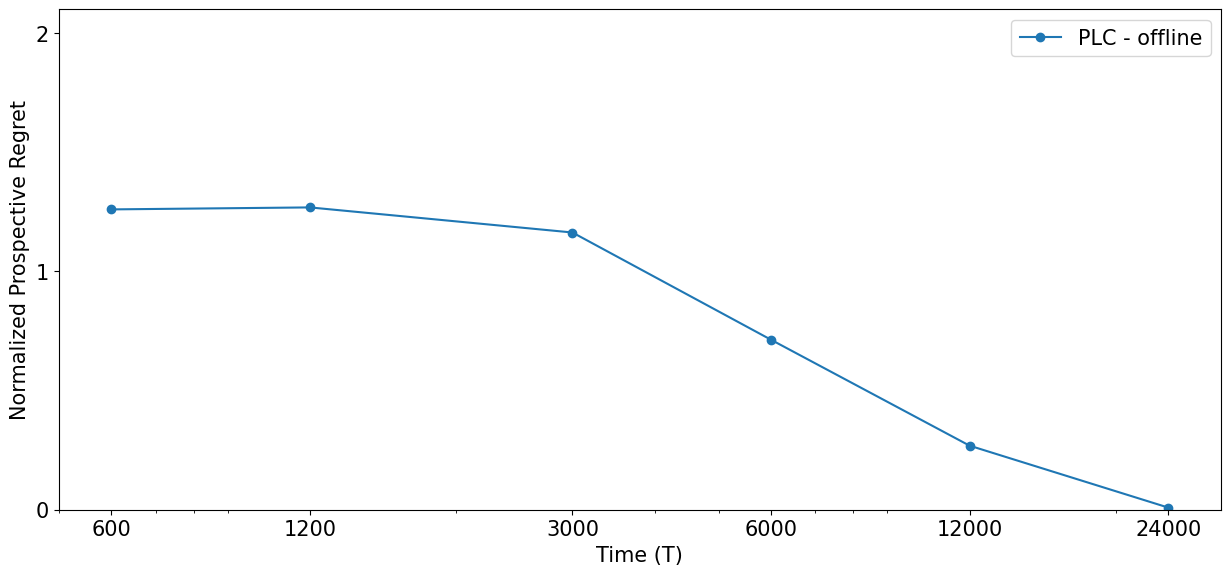

In [68]:
prewards = []
pregrets = []
Ts =  [600,1200,3000,6000,12000,24000]
fontsize = 20
for T in Ts:
    fn = f"../results/2D/RF_oh_w_time{T}_lookahead9_reps{1}.npz"
    data = np.load(fn)
    future_states = data['future_states']
    print(len(future_states))
    irewards_test = [reward_simulate_2d(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    print(irewards_test)
    preward = compute_normalized_future_rewards(irewards_test,60,0.5,normalization = True)
    prewards.append(np.sum(preward))
    pregrets.append((215-(np.sum(preward)))/60)

plt.figure(figsize=(15, 6.5))
plt.plot(Ts,pregrets,marker = 'o',label  = 'PLC - offline')
plt.xscale('log')
xticks = [i for i in Ts]
xticklabels = [str(v) if v in [600,1200,3000,6000,12000,24000] else ""   # hide every 2nd label
               for i, v in enumerate(xticks)]
plt.xticks(xticks, labels=xticklabels,fontsize = fontsize-5)
plt.ylim([0,2.1])
plt.yticks([0,1,2],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize-5)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize-5)
plt.legend(fontsize = fontsize-5)

## Online

In [154]:
def train_model(X, Y, rf=None, sample_weight = None):
    """Train or continue training the XGBRegressor."""
    if rf is None:
        rf = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact",
            n_jobs=-1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=1000, eval_metric="rmse"
        )
        if sample_weight is None:
            rf.fit(X, Y)
        else:
            rf.fit(X, Y,sample_weight = sample_weight)
    else:
        if sample_weight is None:
            rf.fit(X, Y)
        else:
            rf.fit(X, Y,sample_weight = sample_weight)
    return rf

def predict_paths(rf, df_paths, t_start, t_prime):
    n_paths = df_paths.shape[0]
    preds = np.zeros((n_paths, t_prime+1))
    for i in range(t_prime+1):
        if df_paths.shape[1] == 1:
            next_state = df_paths
            next_state_x = np.array([next_state[i][0][0] for i in range(df_paths.shape[0])])
            next_state_y = np.array([next_state[i][0][1] for i in range(df_paths.shape[0])])
            # print(next_state_x,next_state_y)
            cand_pe_x = position_encoder(next_state_x, type="onehot")
            cand_pe_y = position_encoder(next_state_y, type="onehot")
        else:
            next_state = df_paths.iloc[:,i]
            next_state_x = np.array([next_state[i][0] for i in range(df_paths.shape[0])])
            next_state_y = np.array([next_state[i][1] for i in range(df_paths.shape[0])])
            cand_pe_x = position_encoder(next_state_x, type="onehot")
            cand_pe_y = position_encoder(next_state_y, type="onehot")
        curr_time = t_start + 1 + i
        time_emb = time_embedding_np(np.ones(cand_pe_x.shape[0]) * curr_time, tdim=50)
        features = np.hstack([cand_pe_x,cand_pe_y,time_emb])
        preds[:, i] = rf.predict(features)
    return preds

def choose_next_state(rf_action, rf_value, current_state, t_now, t_prime_action, t_prime_value, gamma):
    """Pick best next state based on discounted rewards."""
    df_paths = enumerate_paths_2d(x0=current_state, t_initial=t_now, t_prime=t_prime_action)
    # print(df_paths.shape)
    df_paths_value = np.asarray(df_paths.iloc[:,-1]).reshape(-1,1)
    # print(df_paths,df_paths_value)
    preds_action = predict_paths(rf_action, df_paths, t_now, t_prime_action)
    preds_value = predict_paths(rf_value, df_paths_value, t_now+t_prime_action ,t_prime_value)
    rewards_matrix = preds_action[:, 1:]
    # print(preds_value.shape)
    rewards_matrix = np.hstack([rewards_matrix,preds_value])
    discounts = gamma ** np.arange(0, t_prime_action+1) # Make t_prime_value = 1
    total_disc = (rewards_matrix * discounts).sum(axis=1)
    
    best_idx = np.argmax(total_disc)
    # print(df_paths)
    return df_paths.iloc[best_idx, 1], df_paths, rewards_matrix

def run_inference(rf_action, rf_value, start_state, T_p, t_prime_action, t_prime_value, gamma, rewards_in_period):
    """Generate future trajectory and compute regret."""
    current_state = start_state
    future_states = [current_state]

    for delta_t in range(50):
        next_state, df_paths, preds = choose_next_state(rf_action, rf_value, current_state, T_p + delta_t, t_prime_action, t_prime_value, gamma)
        future_states.append(next_state)
        current_state = next_state

    # compute rewards
    irewards_test = [reward_simulate_2d(future_states[i], T_p+i, rewards_in_period) 
                     for i in range(1, len(future_states))]
    preward = compute_normalized_future_rewards(irewards_test, 50, gamma,normalization=True)

    # optimal path benchmark
    # path, ireward_opt = path_opt(future_states[0], T_p, 100)
    # preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], 100, gamma,normalization=True)
    # pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100

    # plotting
    # plt.plot(np.arange(T_p+1, T_p+101), future_states[1:], label="learned")
    # plt.plot(np.arange(T_p,   T_p+101), path, label="optimal")
    # plt.legend()
    # plt.show()

    return  np.sum(preward).item() / 50


In [158]:
T = 12015
gamma = 0.99
t_prime_action = 9
t_prime_value = 0
DELTA_T = 30
PREGRETS = []
for rep in range(1):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 20000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
    prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)

    state_posencode_oh_x = position_encoder(states[:,:,0], type="onehot")
    state_posencode_oh_y = position_encoder(states[:,:,1], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh_y,state_posencode_oh_x,states[:,0,2:]])

    X_train = new_state_oh[:T]
    Y_train_action = irewards[:T]
    rf_action = train_model(X_train, Y_train_action, None)
    Y_train_value = prewards
    rf_value = train_model(X_train, Y_train_value)

    PREGRET = []
    # T+=15
    current_state = states[T,0,:2]
    future_states = [current_state]
    print(current_state)
    for delta_t in range(1,DELTA_T+1):
        next_state, df_paths, preds = choose_next_state(rf_action,rf_value, current_state, T+delta_t-1, t_prime_action, t_prime_value, gamma)
        next_time = T+delta_t
        print(next_time,next_state)
        next_state_x = np.array([next_state[0]])
        next_state_y = np.array([next_state[1]])
        cand_pe_x = position_encoder(next_state_x, type="onehot")
        cand_pe_y = position_encoder(next_state_y, type="onehot")
        time_emb = time_embedding_np(next_time+1, tdim=50).reshape(1,-1)
        next_features = np.hstack([cand_pe_x,cand_pe_y,time_emb])
        next_reward = reward_simulate_2d(next_state, next_time, rewards_in_period)

        ## PolicyIteration
        X_train = np.vstack([X_train, next_features])
        Y_train_action = np.vstack([Y_train_action.reshape(-1,1), [[next_reward]]])

        rf_action = train_model(X_train, Y_train_action, rf_action)

        Y_train_value = make_weighted_target(Y_train_action, gamma ,T = next_time,normalization = False)
        # is_pos = (Y_train_value > threshold).astype(int)
        # pos = is_pos.sum()
        # neg = len(Y_train_value) - pos
        # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
        # print(X_train.shape,Y_train_value.shape,w.shape)
        rf_value = train_model(X_train, Y_train_value)
        
        current_state = next_state 
        future_states.append(current_state)
        # T_p = delta_t + T
        # start_state = current_state
        # preward_val = run_inference(rf_action, rf_value, start_state, T_p,  t_prime_action, t_prime_value, gamma, rewards_in_period)
        # print(f"rep {rep}, T_train {T_p}, pregret={preward_val:.4f}")
        # PREGRET.append(preward_val)
        
    
    



[5. 2.]
12016 (5, 3)
12017 (5, 4)
12018 (5, 5)
12019 (5, 5)
12020 (5, 5)
12021 (5, 5)
12022 (5, 5)
12023 (5, 4)
12024 (5, 3)
12025 (5, 2)
12026 (5, 1)
12027 (4, 1)
12028 (3, 1)
12029 (2, 1)
12030 (1, 1)
12031 (1, 1)
12032 (1, 1)
12033 (1, 1)
12034 (1, 1)
12035 (1, 1)
12036 (1, 1)
12037 (1, 1)
12038 (2, 1)
12039 (3, 1)
12040 (3, 2)
12041 (4, 2)
12042 (4, 3)
12043 (4, 4)
12044 (5, 4)
12045 (5, 5)


In [152]:
df_paths

,t=12000,t=12001,t=12002,t=12003,t=12004,t=12005,t=12006,t=12007,t=12008,t=12009
0,"(6, 4)","(6, 5)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)"
1,"(6, 4)","(6, 5)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 5)"
2,"(6, 4)","(6, 5)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(5, 6)"
3,"(6, 4)","(6, 5)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 5)","(6, 6)"
4,"(6, 4)","(6, 5)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 6)","(6, 5)","(6, 4)"
...,...,...,...,...,...,...,...,...,...,...
654455,"(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(5, 4)","(5, 4)"
654456,"(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 5)"
654457,"(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 3)"
654458,"(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(6, 4)","(5, 4)"


# Mini Batch
Select the best path with next delta steps and direct train with this delta steps. 

In [206]:
def train_model(X, Y, rf=None, sample_weight = None):
    """Train or continue training the XGBRegressor."""
    if rf is None:
        rf = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact",
            n_jobs=-1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse"
        )
        if sample_weight is None:
            rf.fit(X, Y)
        else:
            rf.fit(X, Y,sample_weight = sample_weight)
    else:
        if sample_weight is None:
            rf.fit(X, Y)
        else:
            rf.fit(X, Y,sample_weight = sample_weight)
    return rf

def predict_paths(rf, df_paths, t_start, t_prime):
    n_paths = df_paths.shape[0]
    preds = np.zeros((n_paths, t_prime+1))
    for i in range(t_prime+1):
        # if df_paths.shape[1] == 1:
        #     next_state = df_paths
        #     # next_state_x = np.array([next_state[i][0][0] for i in range(df_paths.shape[0])])
        #     # next_state_y = np.array([next_state[i][0][1] for i in range(df_paths.shape[0])])
        #     next_state_x = np.array([next_state[i][0] for i in range(df_paths.shape[0])])
        #     next_state_y = np.array([next_state[i][1] for i in range(df_paths.shape[0])])
        #     # print(next_state_x,next_state_y)
        #     cand_pe_x = position_encoder(next_state_x, type="onehot")
        #     cand_pe_y = position_encoder(next_state_y, type="onehot")
        # else:
        next_state = df_paths.iloc[:,i]
        next_state_x = np.array([next_state[i][0] for i in range(df_paths.shape[0])])
        next_state_y = np.array([next_state[i][1] for i in range(df_paths.shape[0])])
        cand_pe_x = position_encoder(next_state_x, type="onehot")
        cand_pe_y = position_encoder(next_state_y, type="onehot")
        curr_time = t_start + 1 + i
        time_emb = time_embedding_np(np.ones(cand_pe_x.shape[0]) * curr_time, tdim=50)
        features = np.hstack([cand_pe_x,cand_pe_y,time_emb])
        preds[:, i] = rf.predict(features)
    return preds

def choose_next_state(rf_action, rf_value, current_state, t_now, t_prime_action, t_prime_value, gamma):
    """Pick best next state based on discounted rewards."""
    df_paths = enumerate_paths_2d(x0=current_state, t_initial=t_now, t_prime=t_prime_action)
    # print(df_paths.shape)
    # df_paths_value = np.asarray(df_paths.iloc[:,-1]).reshape(-1,1)
    df_paths_value = df_paths.iloc[:, [-1]]
    # print(df_paths,df_paths_value)
    preds_action = predict_paths(rf_action, df_paths, t_now, t_prime_action)
    preds_value = predict_paths(rf_value, df_paths_value, t_now+t_prime_action ,t_prime_value)
    rewards_matrix = preds_action[:, 1:]
    # print(preds_value.shape)
    rewards_matrix = np.hstack([rewards_matrix,preds_value])
    discounts = gamma ** np.arange(0, t_prime_action+1) # Make t_prime_value = 1
    total_disc = (rewards_matrix * discounts).sum(axis=1)
    
    best_idx = np.argmax(total_disc)
    # print(df_paths)
    return df_paths.iloc[best_idx, 1:], df_paths, rewards_matrix

def run_inference(rf_action, rf_value, start_state, T_p, t_prime_action, t_prime_value, gamma, rewards_in_period):
    """Generate future trajectory and compute regret."""
    current_state = start_state
    future_states = [current_state]

    for delta_t in range(50):
        next_state, df_paths, preds = choose_next_state(rf_action, rf_value, current_state, T_p + delta_t, t_prime_action, t_prime_value, gamma)
        future_states.append(next_state)
        current_state = next_state

    # compute rewards
    irewards_test = [reward_simulate_2d(future_states[i], T_p+i, rewards_in_period) 
                     for i in range(1, len(future_states))]
    preward = compute_normalized_future_rewards(irewards_test, 50, gamma,normalization=True)

    # optimal path benchmark
    # path, ireward_opt = path_opt(future_states[0], T_p, 100)
    # preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], 100, gamma,normalization=True)
    # pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100

    # plotting
    # plt.plot(np.arange(T_p+1, T_p+101), future_states[1:], label="learned")
    # plt.plot(np.arange(T_p,   T_p+101), path, label="optimal")
    # plt.legend()
    # plt.show()

    return  np.sum(preward).item() / 50


In [212]:
T = 12000
gamma = 0.99
t_prime_action = 9
t_batch = 1
t_prime_value = 0
DELTA_T = 30
PREGRETS = []
for rep in range(1):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 50000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515+rep)
    prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)

    state_posencode_oh_x = position_encoder(states[:,0,0], type="onehot")
    state_posencode_oh_y = position_encoder(states[:,0,1], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh_y,state_posencode_oh_x,states[:,0,2:]])

    X_train = new_state_oh[:T,:]
    Y_train_action = irewards[:T]
    rf_action = train_model(X_train, Y_train_action, None)
    Y_train_value = prewards
    rf_value = train_model(X_train, Y_train_value)

    PREGRET = []
    # T+=15
    current_state = states[T,0,:2]
    future_states = [current_state]
    print(current_state)
    for delta_t in range(1,DELTA_T+1):
        t_init = T+(delta_t-1)*t_batch
        next_states, df_paths, preds = choose_next_state(rf_action,rf_value, current_state, t_init, t_prime_action, t_prime_value, gamma)
        NEXT_FEATURES = []
        NEXT_REWARD = []
        for actor_i in range(t_batch):
            next_time = t_init+actor_i+1
            next_state = next_states[actor_i]
            print(next_time,next_state)
            next_state_x = np.array([next_state[0]])
            next_state_y = np.array([next_state[1]])
            cand_pe_x = position_encoder(next_state_x, type="onehot")
            cand_pe_y = position_encoder(next_state_y, type="onehot")
            time_emb = time_embedding_np(next_time+1, tdim=50).reshape(1,-1)
            next_features = np.hstack([cand_pe_x,cand_pe_y,time_emb])
            next_reward = reward_simulate_2d(next_state, next_time, rewards_in_period)

            current_state = next_state
            future_states.append(current_state)

            NEXT_FEATURES.append(next_features)
            NEXT_REWARD.append(next_reward)
        # print(t_init+t_batch,future_states)
        NEXT_FEATURES_arr = np.vstack([NEXT_FEATURES])[:,0,:]
        NEXT_REWARD_arr = np.vstack([NEXT_REWARD])
        # PolicyIteration
        X_train = np.vstack([X_train, NEXT_FEATURES_arr])
        Y_train_action = np.vstack([Y_train_action.reshape(-1,1), NEXT_REWARD_arr.reshape(-1,1)])

        rf_action = train_model(X_train, Y_train_action, rf_action)
        Y_train_value = make_weighted_target(Y_train_action, gamma ,T = t_init+t_batch,normalization = False)
        # is_pos = (Y_train_value > threshold).astype(int)
        # pos = is_pos.sum()
        # neg = len(Y_train_value) - pos
        # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
        # print(X_train.shape,Y_train_value.shape,w.shape)
        rf_value = train_model(X_train, Y_train_value)
        
        
        # T_p = delta_t + T
        # start_state = current_state
        # preward_val = run_inference(rf_action, rf_value, start_state, T_p,  t_prime_action, t_prime_value, gamma, rewards_in_period)
        # print(f"rep {rep}, T_train {T_p}, pregret={preward_val:.4f}")
        # PREGRET.append(preward_val)
        
    
    



[6. 4.]


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_74817/469101602.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  next_state = next_states[actor_i]


12001 (6, 3)
12002 (5, 3)
12003 (5, 2)
12004 (5, 1)
12005 (4, 1)
12006 (3, 1)
12007 (2, 1)
12008 (2, 1)
12009 (3, 1)
12010 (4, 1)
12011 (5, 1)
12012 (5, 2)
12013 (5, 3)
12014 (5, 4)
12015 (5, 5)
12016 (5, 5)
12017 (5, 5)
12018 (5, 5)
12019 (5, 5)
12020 (5, 5)
12021 (5, 5)
12022 (5, 5)
12023 (5, 5)
12024 (5, 5)
12025 (5, 5)
12026 (5, 4)
12027 (5, 5)
12028 (5, 5)
12029 (5, 4)
12030 (5, 3)


In [187]:
NEXT_FEATURES_arr.shape

(9, 1, 64)

In [184]:
NEXT_FEATURES_arr = np.vstack([NEXT_FEATURES]).reshape()
NEXT_FEATURES[1].shape

TypeError: reshape() takes exactly 1 argument (0 given)

In [185]:
df_paths.shape

(654460, 10)